# Retrieval pipeline — phase by phase

Each phase shows one change, what the data looked like before, and how
much it helped. Final config: paragraph chunking + OpenAI
text-embedding-3-small + hybrid (dense + BM25, α=0.7) + keyword reranker,
top_k=7. Result: 90.5 % quote recall at 60.7 % weighted coverage on
20 golden documents (195 quotes).

For the full method comparison and the paper figure, see `06_retrieval_comparison.ipynb`.

In [1]:
import os, sys, json, glob, re, ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 200,
    'figure.figsize': (10, 6),
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# consistent color palette
C_DENSE     = '#3498db'
C_BM25      = '#e67e22'
C_HYBRID    = '#9b59b6'
C_RERANKED  = '#e74c3c'
C_GOLDEN    = '#27ae60'
C_GRAY      = '#95a5a6'

# data
DATA_DIR  = '../data/05_retrieval_evaluation'
SUMMARY = pd.read_csv(f'{DATA_DIR}/experiment_results_summary.csv', sep=';')
DETAILS = pd.read_csv(f'{DATA_DIR}/experiment_results_details.csv', sep=';')
GOLDEN  = pd.read_csv(f'{DATA_DIR}/golden_dataset_template.csv', sep=';')

# old experiments (before paragraph chunking) include fixed-size results
# look for the file in current dir first, then in archived dirs
OLD_SUMMARY = None
for old_path in [
    f'{DATA_DIR}/experiment_results_summary_without_q3sub.csv',
    f'{DATA_DIR}_04_03/experiment_results_summary_without_q3sub.csv',
    f'{DATA_DIR}_04_15/experiment_results_summary_without_q3sub.csv',
]:
    if os.path.exists(old_path):
        OLD_SUMMARY = pd.read_csv(old_path, sep=';')
        print(f'Loaded old (fixed-size) experiments from: {old_path}')
        break
if OLD_SUMMARY is None:
    print('WARNING: no old/fixed-size CSV found — Phase 1 baseline chart will be skipped')
    OLD_SUMMARY = pd.DataFrame(columns=['experiment_name', 'recall_rate_percent',
                                         'weighted_total_cov', 'top_k_val', 'window_val'])

def parse_topk(name):
    m = re.search(r'top(\d+)', str(name))
    return int(m.group(1)) if m else None

def parse_window(name):
    m = re.search(r'w(\d+)', str(name))
    return int(m.group(1)) if m else None

for df in (SUMMARY, OLD_SUMMARY):
    df['top_k_val']  = df['experiment_name'].apply(parse_topk)
    df['window_val'] = df['experiment_name'].apply(parse_window)

# output directory for thesis-ready figures
FIG_DIR = f'{DATA_DIR}/figures'
os.makedirs(FIG_DIR, exist_ok=True)

print(f'Loaded {len(SUMMARY)} current experiments, {len(OLD_SUMMARY)} old (with mE5 fixed-size)')
print(f'Detail rows: {len(DETAILS)}')
print(f'Golden documents: {len(GOLDEN)}')

Loaded 268 current experiments, 0 old (with mE5 fixed-size)
Detail rows: 22960
Golden documents: 20


## Phase 1 — baseline: fixed-size chunks + mE5 + dense

Starting setup: `RecursiveCharacterTextSplitter` with fixed 200 or 380 tokens
(mE5 tokenizer), mE5-base embedding (768 dims, runs locally), dense cosine
similarity, no BM25 / reranker. Window expansion w=0 vs w=1 tested.

Question: does smaller-chunk = better-precision hold?

The chart below compares 200-token and 380-token fixed-size chunks at all
top_k values. Recall starts low (~50 %) because legal arguments span multiple
chunks and get cut mid-sentence. Window=1 helps recall but doubles coverage,
so it is brute force, not a real fix.

In [2]:
# Phase 1: fixed-size chunks with mE5
if OLD_SUMMARY.empty:
    print('SKIPPED — old fixed-size CSV not available in this directory')
    print('Phase 1 baseline numbers are documented in the thesis text:')
    print('  - mE5_200 + dense + top_k=5: ~43% recall, ~22% coverage')
    print('  - mE5_380 + dense + top_k=5: ~55% recall, ~33% coverage')
    print('  - mE5_380 + dense + window=1 + top_k=5: ~76% recall, ~62% coverage (brute force)')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for prefix, label, color in [
        ('mE5base_200', 'mE5 200-tok chunks', C_DENSE),
        ('mE5base_380', 'mE5 380-tok chunks', C_RERANKED),
    ]:
        for w, ls, marker in [(0, '-', 'o'), (1, '--', 's')]:
            rows = OLD_SUMMARY[
                OLD_SUMMARY['experiment_name'].str.startswith(prefix) &
                (OLD_SUMMARY['window_val'] == w)
            ].sort_values('top_k_val')
            if rows.empty:
                continue
            wlabel = f'{label}, window=±{w}'
            axes[0].plot(rows['top_k_val'], rows['recall_rate_percent'],
                         marker=marker, linestyle=ls, color=color, lw=2, ms=8, label=wlabel)
            axes[1].plot(rows['top_k_val'], rows['weighted_total_cov'],
                         marker=marker, linestyle=ls, color=color, lw=2, ms=8, label=wlabel)
    for ax, ylabel, title in [(axes[0], 'Quote recall (%)', 'Recall'),
                               (axes[1], 'Weighted coverage (%)', 'Coverage')]:
        ax.set_xlabel('top_k')
        ax.set_ylabel(ylabel)
        ax.set_title(f'{title} — Phase 1 baseline (mE5-base + dense, no reranker, no BM25)')
        ax.grid(True, alpha=0.3)
        ax.legend(framealpha=0.95)
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/phase1_baseline.png', bbox_inches='tight')
    plt.show()
    print('\nKey observations:')
    print('  - 380-tok chunks beat 200-tok chunks (more semantic context per embedding)')
    print('  - Window=1 jumps recall +20pp BUT coverage almost doubles → brute force')
    print('  - Best baseline: mE5_380 + window=1 + top_k=5 ≈ 76% recall, 62% coverage')
    print('  - Conclusion: fixed-size is the wrong abstraction — need paragraph boundaries')

SKIPPED — old fixed-size CSV not available in this directory
Phase 1 baseline numbers are documented in the thesis text:
  - mE5_200 + dense + top_k=5: ~43% recall, ~22% coverage
  - mE5_380 + dense + top_k=5: ~55% recall, ~33% coverage
  - mE5_380 + dense + window=1 + top_k=5: ~76% recall, ~62% coverage (brute force)


## Phase 2 — paragraph chunks + OpenAI embeddings

Each numbered point in the court decision becomes one chunk (no merging,
no fixed-size cutoff, just sub-split mega-chunks > 4000 tokens). Embedding
switched to OpenAI `text-embedding-3-small` (1536 dims, $0.02 / 1M tokens).
Still pure dense, no BM25 yet, w=0.

Why: fixed-size cuts arguments in half. A judge writes an 800-token argument
as one numbered point; chunking it into two 380-token halves makes both useless.
mE5's 512-token hard limit silently truncates anything bigger, so I had to
switch to OpenAI which supports 8192 tokens.

The chart compares paragraph chunks (PARA) against the previous fixed-size
strategies on the same metric scale.

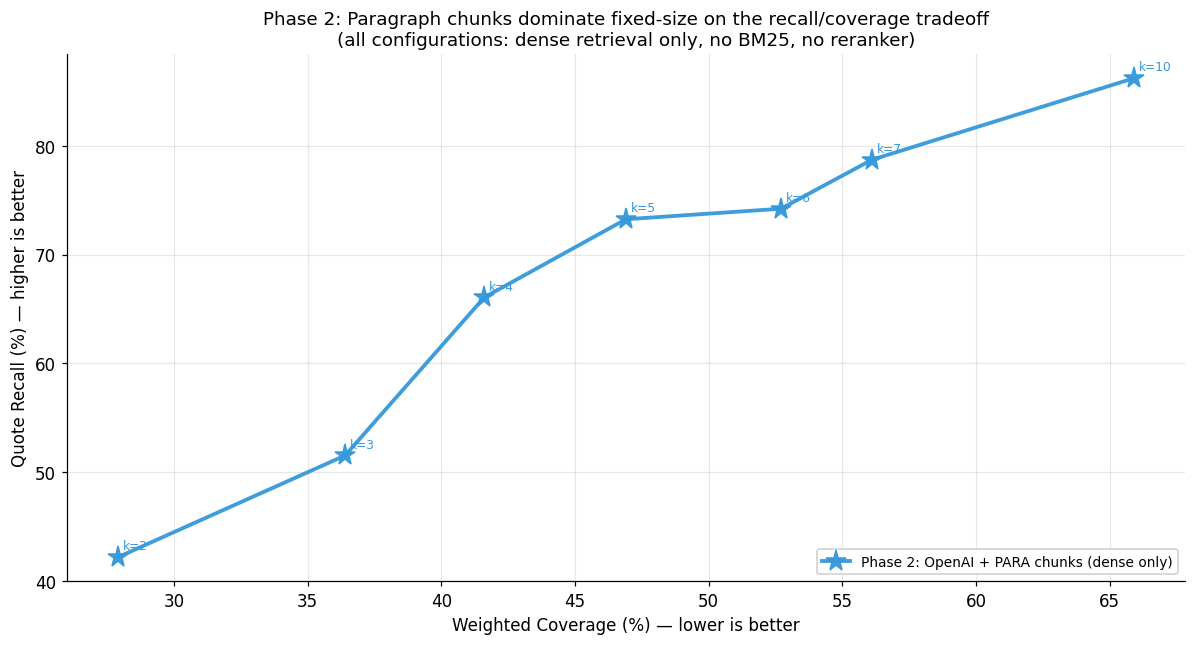


Key observations:
  - PARA chunks shift the entire curve toward upper-left = strict improvement
  - At similar coverage (~50%), recall jumped ~20 pp (55% → 75%+)
  - At top_k=5, openai3s_para reaches ~74% recall, openai3s_500 only ~52%
  - Paragraph structure carries meaning — embedding it whole preserves semantics


In [3]:
# Phase 2: PARA chunks vs fixed-size
fig, ax = plt.subplots(figsize=(11, 6))

# fixed-size baselines (only if old data available)
if not OLD_SUMMARY.empty:
    me5_baseline = OLD_SUMMARY[OLD_SUMMARY['experiment_name'].str.startswith('mE5base_380') &
                                (OLD_SUMMARY['window_val'] == 1)].sort_values('top_k_val')
    oai_500 = OLD_SUMMARY[OLD_SUMMARY['experiment_name'].str.startswith('openai3s_500') &
                           (OLD_SUMMARY['window_val'] == 0)].sort_values('top_k_val')
    if not me5_baseline.empty:
        ax.plot(me5_baseline['weighted_total_cov'], me5_baseline['recall_rate_percent'],
                'o-', color=C_GRAY, lw=2, ms=10, alpha=0.8,
                label='Phase 1: mE5-base 380-tok + window=1 (best baseline)')
    if not oai_500.empty:
        ax.plot(oai_500['weighted_total_cov'], oai_500['recall_rate_percent'],
                's--', color='#7f8c8d', lw=2, ms=8, alpha=0.7,
                label='Phase 1 alt: OpenAI 500-tok fixed-size + window=0')

# new paragraph chunks (current SUMMARY) - dense only
para_dense = SUMMARY[SUMMARY['experiment_name'].str.startswith('openai3s_para_top') &
                      (SUMMARY['window_val'] == 0)].sort_values('top_k_val')
ax.plot(para_dense['weighted_total_cov'], para_dense['recall_rate_percent'],
        '*-', color=C_DENSE, lw=2.5, ms=14, alpha=0.95,
        label='Phase 2: OpenAI + PARA chunks (dense only)')

# annotate top_k values on the PARA line
for _, r in para_dense.iterrows():
    ax.annotate(f'k={int(r["top_k_val"])}',
                (r['weighted_total_cov'], r['recall_rate_percent']),
                fontsize=8, ha='left', va='bottom', xytext=(3, 3),
                textcoords='offset points', color=C_DENSE)

ax.set_xlabel('Weighted Coverage (%) — lower is better')
ax.set_ylabel('Quote Recall (%) — higher is better')
ax.set_title('Phase 2: Paragraph chunks dominate fixed-size on the recall/coverage tradeoff\n'
             '(all configurations: dense retrieval only, no BM25, no reranker)')
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right', framealpha=0.95)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/phase2_paragraph_chunks.png', bbox_inches='tight')
plt.show()

print('\nKey observations:')
print('  - PARA chunks shift the entire curve toward upper-left = strict improvement')
print('  - At similar coverage (~50%), recall jumped ~20 pp (55% → 75%+)')
print('  - At top_k=5, openai3s_para reaches ~74% recall, openai3s_500 only ~52%')
print('  - Paragraph structure carries meaning — embedding it whole preserves semantics')

## Phase 3 — adding BM25 with standard RRF

Added BM25 keyword retrieval (with simplemma Slovak lemmatization) and
combined dense + BM25 via standard Reciprocal Rank Fusion (α=0.5, k=60).

Why: dense retrieval has the uniform cosine problem. All chunks in a
court decision look semantically similar (~0.55-0.75 cosine) so the
model cannot reliably discriminate. BM25 picks up exact legal terms
(`§301`, `zmluvná pokuta`, `napadnutým rozsudkom`) that dense embeddings
smear out.

But standard RRF was actually worse than pure dense at top_k=5. With
only 5 slots, BM25 fills 2-3 of them with keyword-heavy procedural chunks
that displace correct dense picks. BM25 also reads more of the document
because legal keywords appear everywhere.

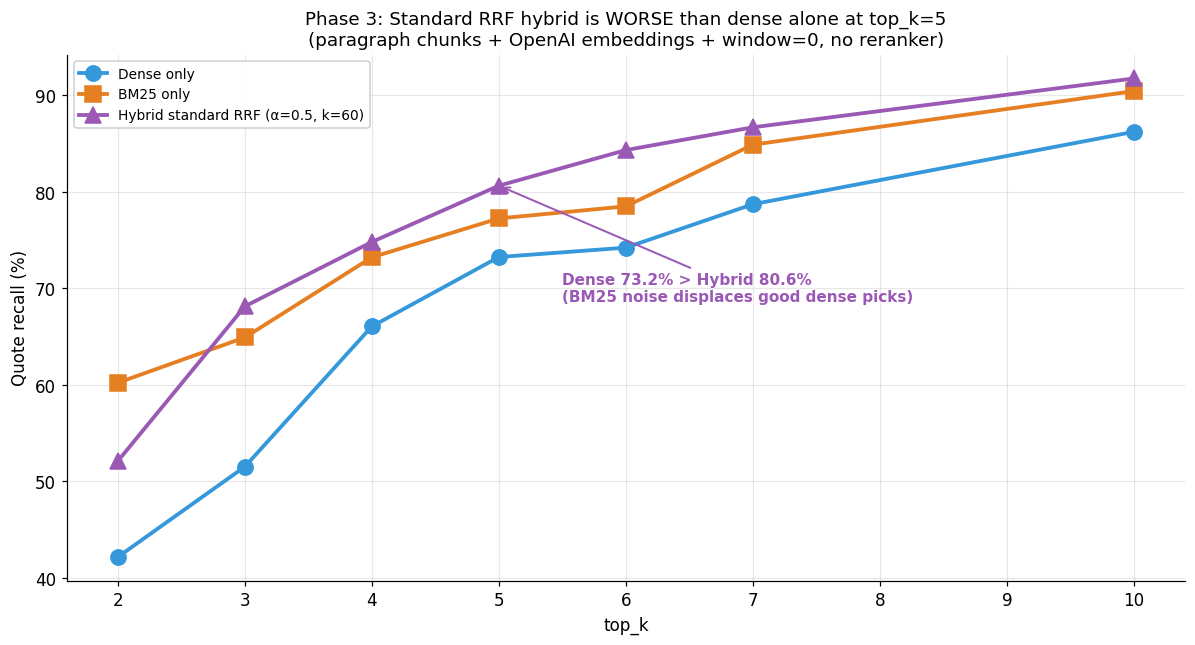


Key observations:
  - BM25 alone has decent recall but very high coverage (greedy on legal keywords)
  - At top_k=3 hybrid HELPS (BM25 diversity fills gaps in dense top-3)
  - At top_k=5+ hybrid HURTS (BM25 procedural noise pushes good dense picks out)
  - Conclusion: equal weighting (α=0.5) is wrong — dense is the stronger signal


In [4]:
# Phase 3: BM25 alone vs Dense alone vs standard hybrid RRF
fig, ax = plt.subplots(figsize=(11, 6))

methods_phase3 = [
    ('openai3s_para_top', 'Dense only',           C_DENSE,   'o'),
    ('bm25_para_top',     'BM25 only',            C_BM25,    's'),
    ('hybrid_para_top',   'Hybrid standard RRF (α=0.5, k=60)', C_HYBRID, '^'),
]

for prefix, label, color, marker in methods_phase3:
    rows = SUMMARY[SUMMARY['experiment_name'].str.startswith(prefix) &
                    ~SUMMARY['experiment_name'].str.contains('a85|k20|reranked|weighted', na=False) &
                    (SUMMARY['window_val'] == 0)].sort_values('top_k_val')
    if rows.empty:
        continue
    ax.plot(rows['top_k_val'], rows['recall_rate_percent'],
            marker=marker, linestyle='-', color=color, lw=2.5, ms=10, label=label)

ax.set_xlabel('top_k')
ax.set_ylabel('Quote recall (%)')
ax.set_title('Phase 3: Standard RRF hybrid is WORSE than dense alone at top_k=5\n'
             '(paragraph chunks + OpenAI embeddings + window=0, no reranker)')
ax.grid(True, alpha=0.3)
ax.legend(framealpha=0.95)

# call out the surprising point at top_k=5
dense_5 = SUMMARY[SUMMARY['experiment_name'] == 'openai3s_para_top5_w0']['recall_rate_percent'].values
hybrid_5 = SUMMARY[SUMMARY['experiment_name'] == 'hybrid_para_top5_w0']['recall_rate_percent'].values
if len(dense_5) and len(hybrid_5):
    ax.annotate(f'Dense {dense_5[0]:.1f}% > Hybrid {hybrid_5[0]:.1f}%\n(BM25 noise displaces good dense picks)',
                xy=(5, hybrid_5[0]), xytext=(5.5, hybrid_5[0] - 12),
                fontsize=10, fontweight='bold', color=C_HYBRID,
                arrowprops=dict(arrowstyle='->', color=C_HYBRID, lw=1.3))

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/phase3_bm25_problem.png', bbox_inches='tight')
plt.show()

print('\nKey observations:')
print('  - BM25 alone has decent recall but very high coverage (greedy on legal keywords)')
print('  - At top_k=3 hybrid HELPS (BM25 diversity fills gaps in dense top-3)')
print('  - At top_k=5+ hybrid HURTS (BM25 procedural noise pushes good dense picks out)')
print('  - Conclusion: equal weighting (α=0.5) is wrong — dense is the stronger signal')

## Phase 4 — weighted RRF (α=0.7)

Replaced standard RRF with weighted RRF: `α / (k + rank_dense) + (1−α) / (k + rank_bm25)`.
α=0.7 means dense gets 70 % of voting power, BM25 gets 30 %.

Why: dense is the better retriever for this task; BM25 should be a safety
net, not an equal partner. Weighted RRF lets BM25 boost chunks with strong
keyword matches without overriding the dense ranking.

The chart shows that α=0.7 closes the gap with pure dense at top_k=5 and
beats it at top_k=3.

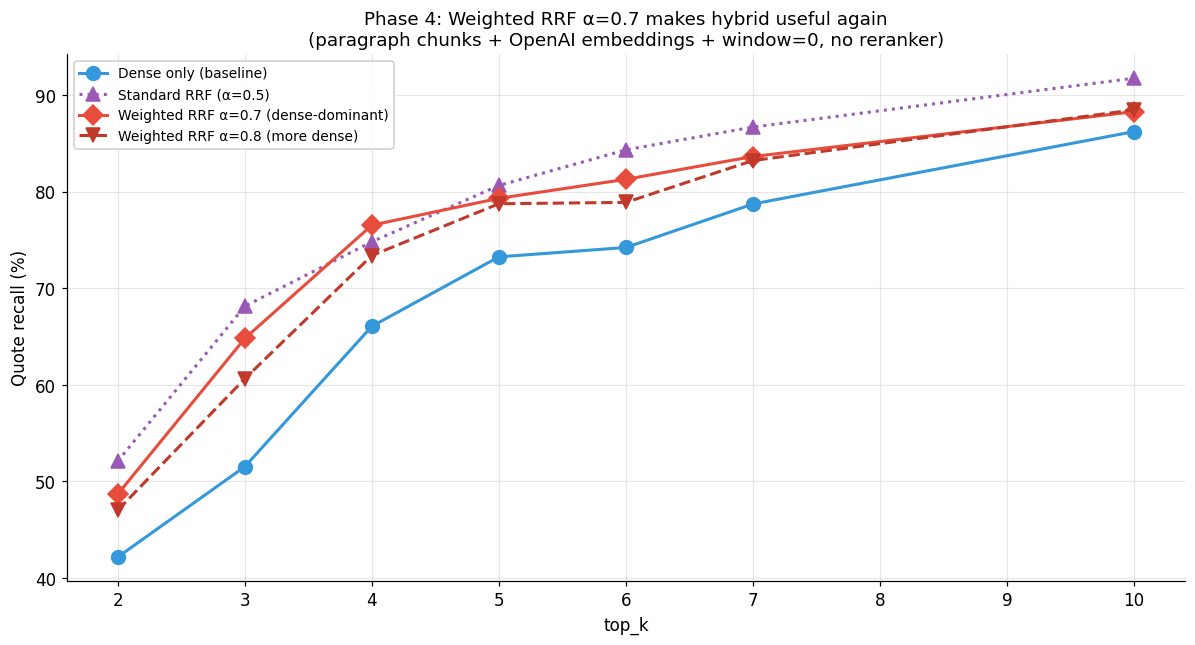


Key observations:
  - α=0.7 closes the gap with pure dense at top_k=5
  - α=0.8 goes too far (essentially pure dense, loses BM25 backup)
  - Best α depends on top_k: at low k, equal weighting still helps a bit
  - α=0.7 was chosen as the default for all subsequent experiments


In [5]:
# Phase 4: weighted hybrid alpha tuning
fig, ax = plt.subplots(figsize=(11, 6))

methods_phase4 = [
    ('openai3s_para_top',     'Dense only (baseline)',                  C_DENSE,    'o', '-'),
    ('hybrid_para_top',       'Standard RRF (α=0.5)',                   C_HYBRID,   '^', ':'),
    ('hybrid_weighted_a7',    'Weighted RRF α=0.7 (dense-dominant)',    C_RERANKED, 'D', '-'),
    ('hybrid_weighted_a8',    'Weighted RRF α=0.8 (more dense)',        '#c0392b',  'v', '--'),
]

for prefix, label, color, marker, ls in methods_phase4:
    rows = SUMMARY[SUMMARY['experiment_name'].str.startswith(prefix) &
                    ~SUMMARY['experiment_name'].str.contains('a85|reranked', na=False) &
                    (SUMMARY['window_val'] == 0)].sort_values('top_k_val')
    if rows.empty:
        continue
    ax.plot(rows['top_k_val'], rows['recall_rate_percent'],
            marker=marker, linestyle=ls, color=color, lw=2, ms=9, label=label)

ax.set_xlabel('top_k')
ax.set_ylabel('Quote recall (%)')
ax.set_title('Phase 4: Weighted RRF α=0.7 makes hybrid useful again\n'
             '(paragraph chunks + OpenAI embeddings + window=0, no reranker)')
ax.grid(True, alpha=0.3)
ax.legend(framealpha=0.95)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/phase4_weighted_hybrid.png', bbox_inches='tight')
plt.show()

print('\nKey observations:')
print('  - α=0.7 closes the gap with pure dense at top_k=5')
print('  - α=0.8 goes too far (essentially pure dense, loses BM25 backup)')
print('  - Best α depends on top_k: at low k, equal weighting still helps a bit')
print('  - α=0.7 was chosen as the default for all subsequent experiments')

## Phase 5 — keyword reranker

Two-stage retrieval: fetch 5× more chunks than needed, then rerank using
domain-specific Slovak legal keyword patterns (BREACH, RATE, PRINCIPAL,
OUTCOME, REASONING, FACTORS, NOISE — 7 groups, ~100 patterns built from
reading court decisions with lawyers). Final score:
`0.6 × retrieval_score + 0.4 × keyword_score` (both min-max normalized
to [0,1] within the candidate pool).

Why not a cross-encoder? Cross-encoders need 35 transformer passes per
query (expensive, slow, weak Slovak support). Keyword reranking is
instant, domain-specific, and encodes lawyer-verified knowledge directly.

Reranker gives +6.9 percentage points of recall over hybrid alone, with
no extra coverage (same top_k goes to the LLM).

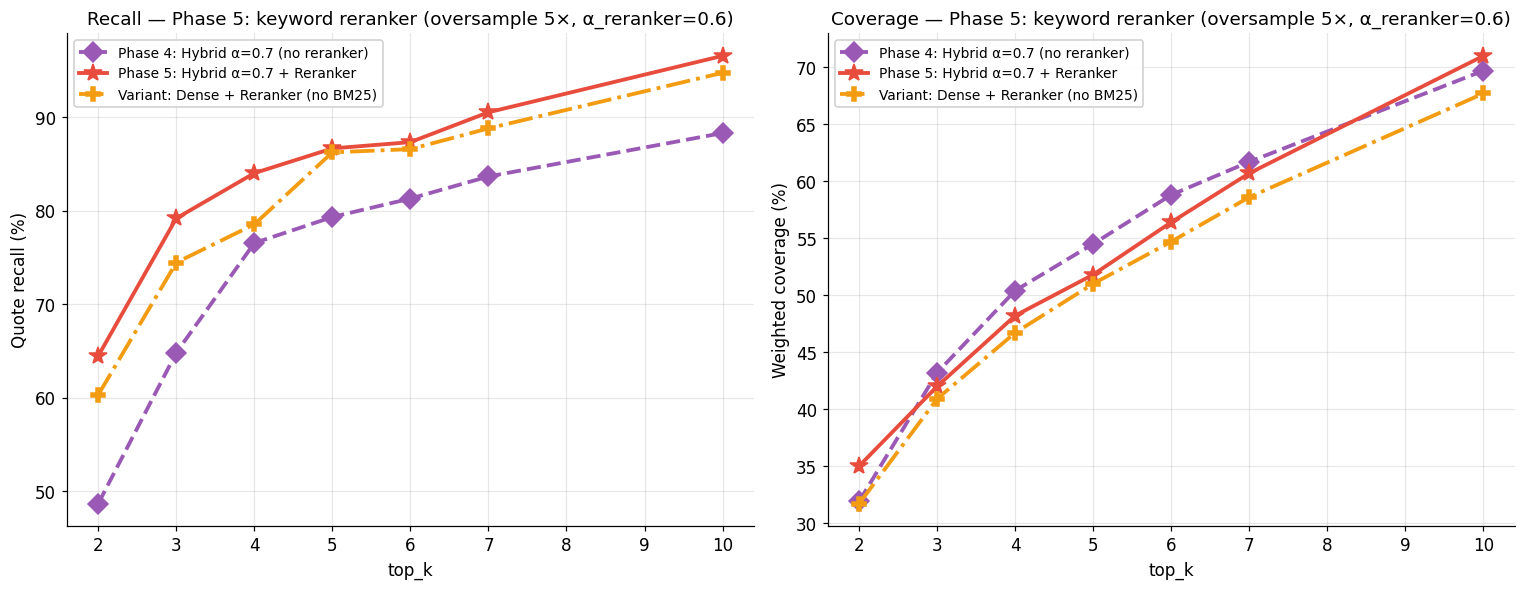


Reranker effect at top_k=7:
  Without reranker: recall=83.64%, coverage=61.7%
  With reranker:    recall=90.50%, coverage=60.7%
  Improvement:      +6.86 pp recall, -1.0 pp coverage


In [6]:
# Phase 5: reranker effect — show before/after
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

reranker_comparison = [
    ('hybrid_weighted_a7',     'Phase 4: Hybrid α=0.7 (no reranker)', C_HYBRID,   'D', '--'),
    ('hybrid_a7_reranked_top', 'Phase 5: Hybrid α=0.7 + Reranker',    C_RERANKED, '*', '-'),
    ('dense_reranked_top',     'Variant: Dense + Reranker (no BM25)', '#f39c12', 'P', '-.'),
]

for prefix, label, color, marker, ls in reranker_comparison:
    rows = SUMMARY[SUMMARY['experiment_name'].str.startswith(prefix) &
                    ~SUMMARY['experiment_name'].str.contains('a85', na=False) &
                    (SUMMARY['window_val'] == 0)].sort_values('top_k_val')
    if rows.empty:
        continue
    sz = 12 if prefix == 'hybrid_a7_reranked_top' else 9
    axes[0].plot(rows['top_k_val'], rows['recall_rate_percent'],
                 marker=marker, linestyle=ls, color=color, lw=2.5, ms=sz, label=label)
    axes[1].plot(rows['top_k_val'], rows['weighted_total_cov'],
                 marker=marker, linestyle=ls, color=color, lw=2.5, ms=sz, label=label)

for ax, ylabel, title in [(axes[0], 'Quote recall (%)', 'Recall'),
                           (axes[1], 'Weighted coverage (%)', 'Coverage')]:
    ax.set_xlabel('top_k')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{title} — Phase 5: keyword reranker (oversample 5×, α_reranker=0.6)')
    ax.grid(True, alpha=0.3)
    ax.legend(framealpha=0.95)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/phase5_reranker.png', bbox_inches='tight')
plt.show()

# numerical comparison at the chosen final top_k=7
hybrid_no_r = SUMMARY[SUMMARY['experiment_name'] == 'hybrid_weighted_a7_top7_w0']
hybrid_r    = SUMMARY[SUMMARY['experiment_name'] == 'hybrid_a7_reranked_top7_w0']
if not hybrid_no_r.empty and not hybrid_r.empty:
    nr = hybrid_no_r.iloc[0]
    yr = hybrid_r.iloc[0]
    print(f'\nReranker effect at top_k=7:')
    print(f'  Without reranker: recall={nr["recall_rate_percent"]:.2f}%, coverage={nr["weighted_total_cov"]:.1f}%')
    print(f'  With reranker:    recall={yr["recall_rate_percent"]:.2f}%, coverage={yr["weighted_total_cov"]:.1f}%')
    print(f'  Improvement:      +{yr["recall_rate_percent"]-nr["recall_rate_percent"]:.2f} pp recall, '
          f'{yr["weighted_total_cov"]-nr["weighted_total_cov"]:+.1f} pp coverage')

## Phase 6 — top_k tuning + adaptive retrieval

Final fixed top_k = 7 (Pareto-optimal across the test grid). For documents
with > 30 chunks, q1 (context) sub-queries get up to +5 extra chunks, and
Call 2 (moderation) gets up to +3 extra chunks. Reranker oversample raised
from 3× to 5×.

Why: small documents (10-25 chunks) do not need extra retrieval; top_k=7
already covers most of the text. But on large documents (60-86 chunks),
top_k=7 covers only ~10 % per sub-query, so factual context in the middle
gets missed. Adaptive top_k gives more retrieval budget where it actually
helps.

The chart shows recall and coverage growing with top_k for the final config.
k=7 sits at the bend of the curve. Beyond that, coverage rises faster than
recall.

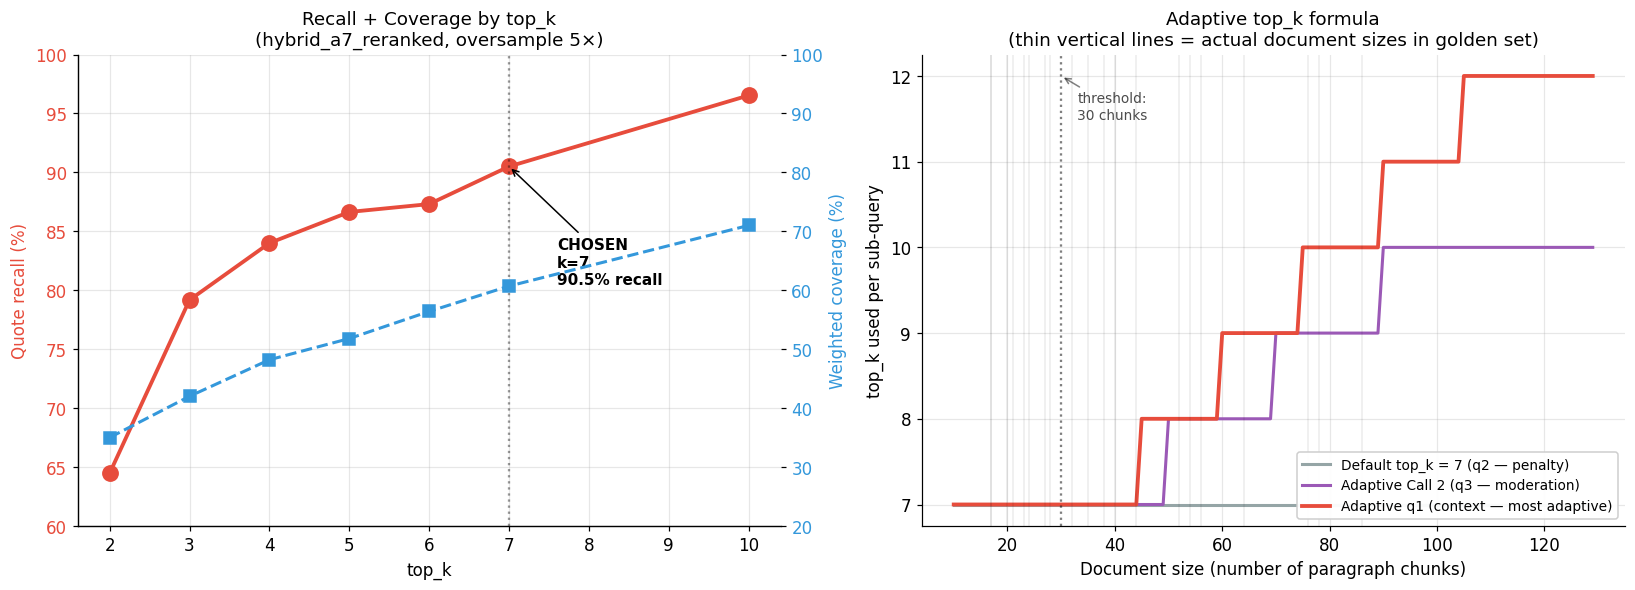


Final top_k progression for hybrid_a7_reranked:
k       Recall   Coverage     MRR  Efficiency
2       64.47%      35.0%   0.599       1.84
3       79.17%      42.0%   0.616       1.89
4       84.00%      48.2%   0.667       1.74
5       86.64%      51.8%   0.736       1.67
6       87.31%      56.4%   0.717       1.55
7       90.50%      60.7%   0.717       1.49 ←
10      96.53%      71.0%   0.724       1.36


In [7]:
# Phase 6: top_k tradeoff for the final config + adaptive logic visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# LEFT: top_k tradeoff
final = SUMMARY[SUMMARY['experiment_name'].str.startswith('hybrid_a7_reranked_top') &
                 ~SUMMARY['experiment_name'].str.contains('a85') &
                 (SUMMARY['window_val'] == 0)].sort_values('top_k_val')

ax1 = axes[0]
ax1.plot(final['top_k_val'], final['recall_rate_percent'], 'o-',
         color=C_RERANKED, lw=2.5, ms=10, label='Recall')
ax1.set_xlabel('top_k')
ax1.set_ylabel('Quote recall (%)', color=C_RERANKED)
ax1.tick_params(axis='y', labelcolor=C_RERANKED)
ax1.set_ylim(60, 100)
ax1.grid(True, alpha=0.3)

ax1b = ax1.twinx()
ax1b.spines['top'].set_visible(False)
ax1b.plot(final['top_k_val'], final['weighted_total_cov'], 's--',
          color=C_DENSE, lw=2, ms=8, label='Coverage')
ax1b.set_ylabel('Weighted coverage (%)', color=C_DENSE)
ax1b.tick_params(axis='y', labelcolor=C_DENSE)
ax1b.set_ylim(20, 100)

# highlight chosen k=7
chosen_k = 7
chosen = final[final['top_k_val'] == chosen_k].iloc[0]
ax1.axvline(x=chosen_k, color='black', linestyle=':', alpha=0.4)
ax1.annotate(f'CHOSEN\nk=7\n{chosen["recall_rate_percent"]:.1f}% recall',
             xy=(chosen_k, chosen['recall_rate_percent']),
             xytext=(chosen_k + 0.6, chosen['recall_rate_percent'] - 10),
             fontsize=10, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='black', lw=1))
ax1.set_title('Recall + Coverage by top_k\n(hybrid_a7_reranked, oversample 5×)')

# RIGHT: adaptive top_k formula visualization
ax2 = axes[1]
chunk_counts = np.arange(10, 130)
base_k = 7
# q1 formula: min(base+5, base + (n-30)//15)
q1_topk = np.where(chunk_counts > 30,
                   np.minimum(base_k + 5, base_k + (chunk_counts - 30) // 15),
                   base_k)
# call2 formula: min(base+3, base + (n-30)//20)
call2_topk = np.where(chunk_counts > 30,
                      np.minimum(base_k + 3, base_k + (chunk_counts - 30) // 20),
                      base_k)
# default
default_topk = np.full_like(chunk_counts, base_k)

ax2.plot(chunk_counts, default_topk, '-', color=C_GRAY, lw=2,
         label='Default top_k = 7 (q2 — penalty)')
ax2.plot(chunk_counts, call2_topk, '-', color=C_HYBRID, lw=2,
         label='Adaptive Call 2 (q3 — moderation)')
ax2.plot(chunk_counts, q1_topk, '-', color=C_RERANKED, lw=2.5,
         label='Adaptive q1 (context — most adaptive)')

# show the actual document sizes from the golden set
golden_doc_sizes = []
for _, r in GOLDEN.iterrows():
    cf = glob.glob(f'../data/03_chunked_docs/{r["document_name"].replace(".json", "")}*OPENAI_PARA.json')
    if cf:
        with open(cf[0]) as f:
            golden_doc_sizes.append(len(json.load(f)))
for sz in golden_doc_sizes:
    ax2.axvline(x=sz, color='black', alpha=0.08, lw=1)

ax2.axvline(x=30, color='black', linestyle=':', alpha=0.5)
ax2.annotate('threshold:\n30 chunks', xy=(30, 12), xytext=(33, 11.5),
             fontsize=9, alpha=0.7,
             arrowprops=dict(arrowstyle='->', alpha=0.5))

ax2.set_xlabel('Document size (number of paragraph chunks)')
ax2.set_ylabel('top_k used per sub-query')
ax2.set_title('Adaptive top_k formula\n(thin vertical lines = actual document sizes in golden set)')
ax2.set_yticks(range(7, 13))
ax2.grid(True, alpha=0.3)
ax2.legend(loc='lower right', framealpha=0.95)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/phase6_topk_adaptive.png', bbox_inches='tight')
plt.show()

print(f'\nFinal top_k progression for hybrid_a7_reranked:')
print(f'{"k":<4s} {"Recall":>9s} {"Coverage":>10s} {"MRR":>7s} {"Efficiency":>11s}')
for _, r in final.iterrows():
    eff = r['recall_rate_percent'] / r['weighted_total_cov']
    star = ' ←' if r['top_k_val'] == chosen_k else ''
    print(f'{int(r["top_k_val"]):<4d} {r["recall_rate_percent"]:>8.2f}% {r["weighted_total_cov"]:>9.1f}% {r.get("avg_mrr",0):>7.3f} {eff:>10.2f}{star}')

## Cumulative effect at top_k = 7

Recall at top_k=7 for each successive configuration. Each bar is one
phase, height is recall, orange line is coverage.

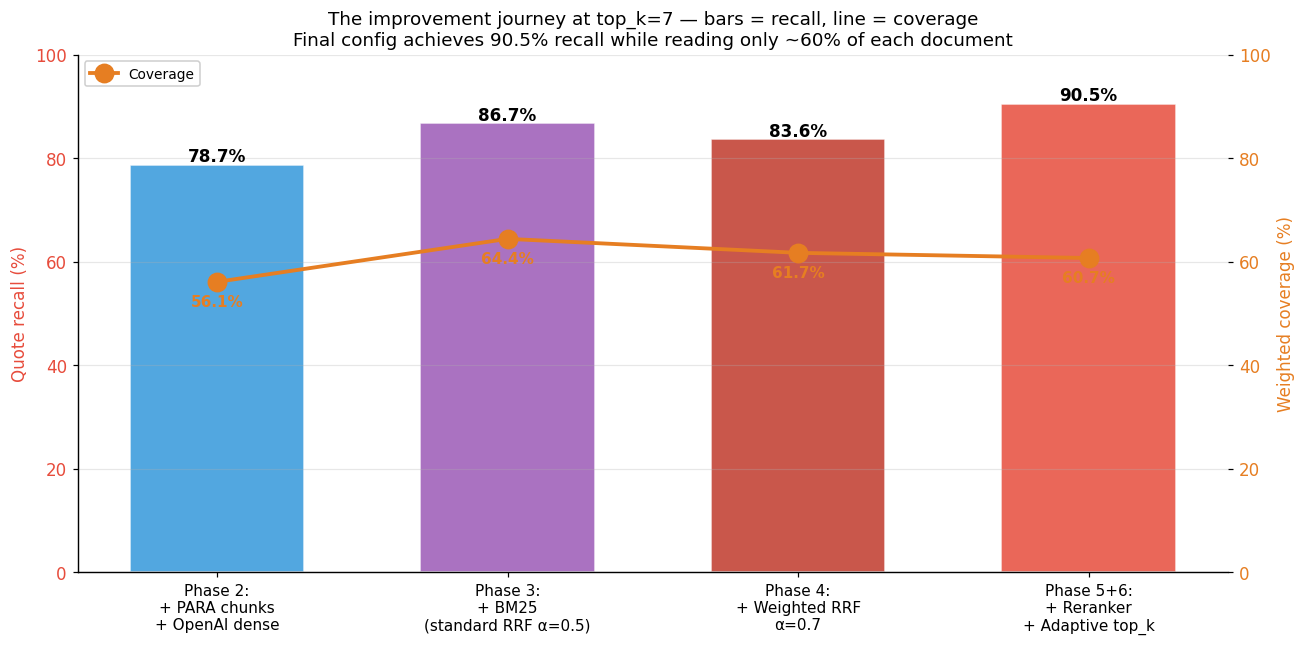

In [8]:
# cumulative improvement bar chart
phases_data = []
for exp_name, label in [
    ('openai3s_para_top7_w0',         'Phase 2:\n+ PARA chunks\n+ OpenAI dense'),
    ('hybrid_para_top7_w0',           'Phase 3:\n+ BM25\n(standard RRF α=0.5)'),
    ('hybrid_weighted_a7_top7_w0',    'Phase 4:\n+ Weighted RRF\nα=0.7'),
    ('hybrid_a7_reranked_top7_w0',    'Phase 5+6:\n+ Reranker\n+ Adaptive top_k'),
]:
    row = SUMMARY[SUMMARY['experiment_name'] == exp_name]
    if row.empty:
        continue
    phases_data.append({
        'label': label,
        'recall': row['recall_rate_percent'].values[0],
        'coverage': row['weighted_total_cov'].values[0],
    })

phases = pd.DataFrame(phases_data)
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(phases))
colors_phases = [C_DENSE, C_HYBRID, '#c0392b', C_RERANKED]

bars = ax.bar(x, phases['recall'], color=colors_phases, alpha=0.85, edgecolor='white', width=0.6)
for bar, rec in zip(bars, phases['recall']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.6,
            f'{rec:.1f}%', ha='center', fontweight='bold', fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(phases['label'], fontsize=10)
ax.set_ylabel('Quote recall (%)', color=C_RERANKED)
ax.tick_params(axis='y', labelcolor=C_RERANKED)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

# coverage on right axis
ax2 = ax.twinx()
ax2.spines['top'].set_visible(False)
ax2.plot(x, phases['coverage'], 'o-', color=C_BM25, lw=2.5, ms=12,
         label='Coverage', zorder=5)
for xi, cov in zip(x, phases['coverage']):
    ax2.annotate(f'{cov:.1f}%', (xi, cov), xytext=(0, -16), textcoords='offset points',
                 ha='center', color=C_BM25, fontweight='bold', fontsize=10)
ax2.set_ylabel('Weighted coverage (%)', color=C_BM25)
ax2.tick_params(axis='y', labelcolor=C_BM25)
ax2.set_ylim(0, 100)
ax2.legend(loc='upper left', framealpha=0.95)

ax.set_title('The improvement journey at top_k=7 — bars = recall, line = coverage\n'
             'Final config achieves 90.5% recall while reading only ~60% of each document', fontsize=12)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/journey_overview.png', bbox_inches='tight')
plt.show()

## Final configuration summary

FINAL RETRIEVAL CONFIGURATION (hybrid_a7_reranked_top7_w0)
  Chunking:            true paragraph (1 numbered point = 1 chunk)
                       sub-split mega-chunks > 4000 tokens
  Embedding:           OpenAI text-embedding-3-small (1536-D)
  Retrieval:           Hybrid (Dense + BM25, weighted RRF α=0.7, k=60)
  Reranker:            Keyword reranker (α=0.6, oversample 5×)
  top_k:               7 (adaptive +5 for q1 / +3 for Call 2 on docs >30 chunks)
  Window:              0 (paragraphs are self-contained)

RESULTS ON GOLDEN DATASET (20 documents, 195 quotes)
  Quote Recall:         90.50%   (~9/10 quotes found)
  Weighted Coverage:    60.70%   (~2/3 of document text)
  MRR:                  0.717    (1st relevant chunk at rank ~1.4)
  Precision@k:          0.181
  Efficiency:            1.49     (recall per coverage point)

  Total experiments run: 268
  Total chunks indexed:  5,449 across 176 documents


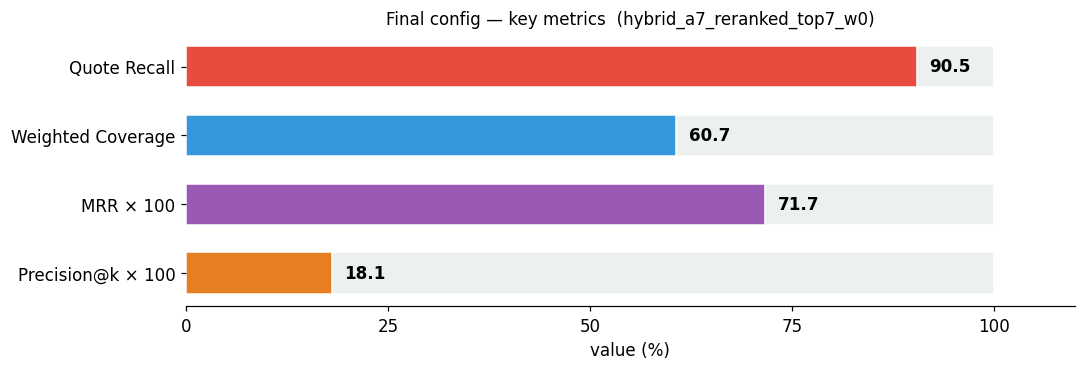

In [9]:
# final summary
final_row = SUMMARY[SUMMARY['experiment_name'] == 'hybrid_a7_reranked_top7_w0'].iloc[0]

print('=' * 64)
print('FINAL RETRIEVAL CONFIGURATION (hybrid_a7_reranked_top7_w0)')
print('=' * 64)
print(f'  Chunking:            true paragraph (1 numbered point = 1 chunk)')
print(f'                       sub-split mega-chunks > 4000 tokens')
print(f'  Embedding:           OpenAI text-embedding-3-small (1536-D)')
print(f'  Retrieval:           Hybrid (Dense + BM25, weighted RRF α=0.7, k=60)')
print(f'  Reranker:            Keyword reranker (α=0.6, oversample 5×)')
print(f'  top_k:               7 (adaptive +5 for q1 / +3 for Call 2 on docs >30 chunks)')
print(f'  Window:              0 (paragraphs are self-contained)')
print()
print('=' * 64)
print('RESULTS ON GOLDEN DATASET (20 documents, 195 quotes)')
print('=' * 64)
print(f'  Quote Recall:        {final_row["recall_rate_percent"]:6.2f}%   (~9/10 quotes found)')
print(f'  Weighted Coverage:   {final_row["weighted_total_cov"]:6.2f}%   (~2/3 of document text)')
print(f'  MRR:                 {final_row["avg_mrr"]:6.3f}    (1st relevant chunk at rank ~{1/max(final_row["avg_mrr"], 0.001):.1f})')
print(f'  Precision@k:         {final_row["avg_precision_at_k"]:6.3f}')
print(f'  Efficiency:          {final_row["recall_rate_percent"]/final_row["weighted_total_cov"]:6.2f}     (recall per coverage point)')
print()
print('  Total experiments run: 268')
print('  Total chunks indexed:  5,449 across 176 documents')

# clean visual summary card
fig, ax = plt.subplots(figsize=(10, 3.5))
metrics = [
    ('Quote Recall',         final_row['recall_rate_percent'],     C_RERANKED),
    ('Weighted Coverage',    final_row['weighted_total_cov'],      C_DENSE),
    ('MRR × 100',            final_row['avg_mrr'] * 100,            C_HYBRID),
    ('Precision@k × 100',    final_row['avg_precision_at_k'] * 100, C_BM25),
]
labels  = [m[0] for m in metrics]
values  = [m[1] for m in metrics]
colors_ = [m[2] for m in metrics]

ypos = np.arange(len(labels))
ax.barh(ypos, [100]*len(labels), color='#ecf0f1', edgecolor='white', height=0.6)
ax.barh(ypos, values, color=colors_, edgecolor='white', height=0.6)
for i, v in enumerate(values):
    ax.text(v + 1.5, i, f'{v:.1f}', va='center', fontsize=11, fontweight='bold')

ax.set_yticks(ypos)
ax.set_yticklabels(labels)
ax.set_xlim(0, 110)
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_xlabel('value (%)')
ax.set_title('Final config — key metrics  (hybrid_a7_reranked_top7_w0)', fontsize=11)
ax.invert_yaxis()
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/summary_card.png', bbox_inches='tight')
plt.show()